In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../datasets/ai4i2020.csv")

In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:

df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [8]:
df.shape

df.columns

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [9]:
df.isnull().sum()

df.duplicated().sum()

np.int64(0)

In [10]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [11]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

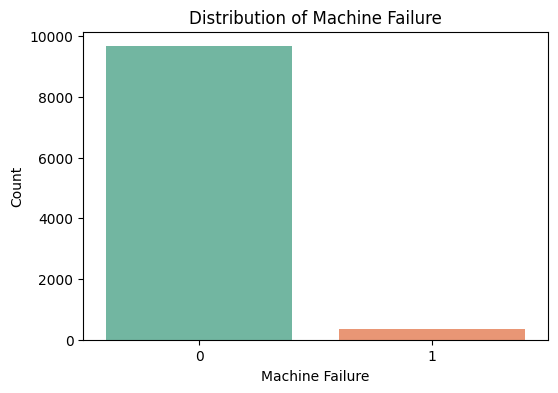

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Machine failure",
    palette="Set2"
)

plt.title("Distribution of Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.show()

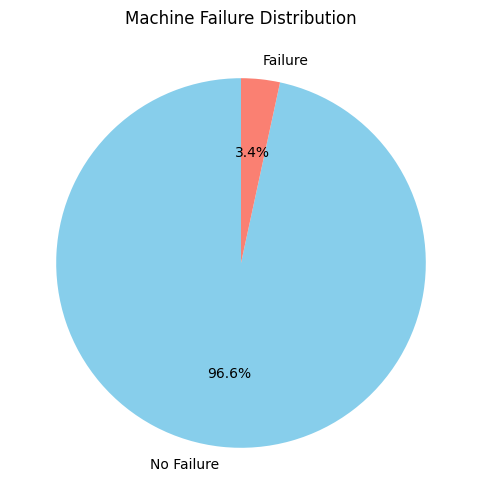

In [13]:
failure_counts = df["Machine failure"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    failure_counts,
    labels=["No Failure","Failure"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue","salmon"]
)

plt.title("Machine Failure Distribution")

plt.show()

In [14]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

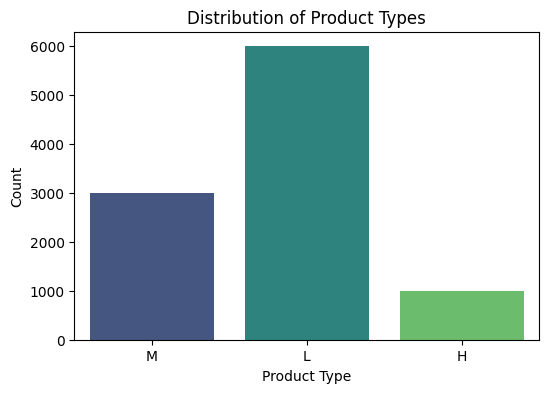

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Type",
    palette="viridis"
)

plt.title("Distribution of Product Types")
plt.xlabel("Product Type")
plt.ylabel("Count")

plt.show()

In [16]:
pd.crosstab(
    df["Type"],
    df["Machine failure"]
)

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


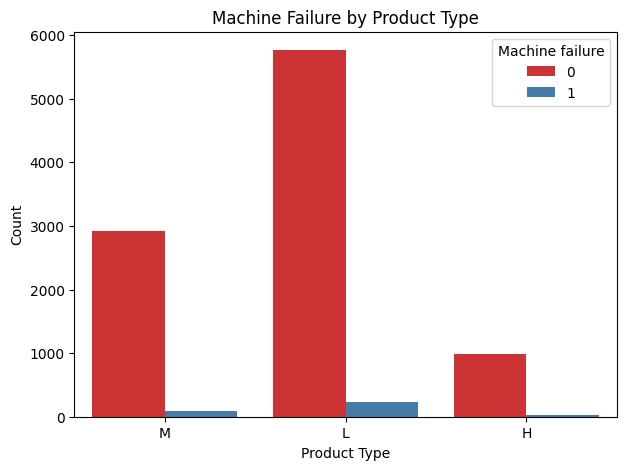

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Type",
    hue="Machine failure",
    palette="Set1"
)

plt.title("Machine Failure by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Count")

plt.show()

In [18]:
numerical_columns=[
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

In [19]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


In [20]:
df[numerical_columns].skew()

Air temperature [K]        0.114274
Process temperature [K]    0.015027
Rotational speed [rpm]     1.993171
Torque [Nm]               -0.009517
Tool wear [min]            0.027292
dtype: float64

In [21]:
df[numerical_columns].skew()

Air temperature [K]        0.114274
Process temperature [K]    0.015027
Rotational speed [rpm]     1.993171
Torque [Nm]               -0.009517
Tool wear [min]            0.027292
dtype: float64

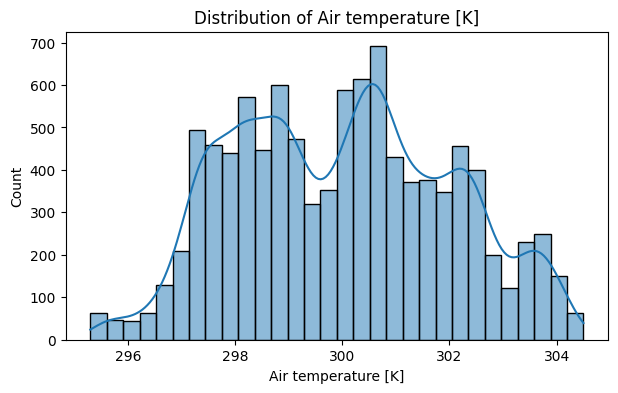

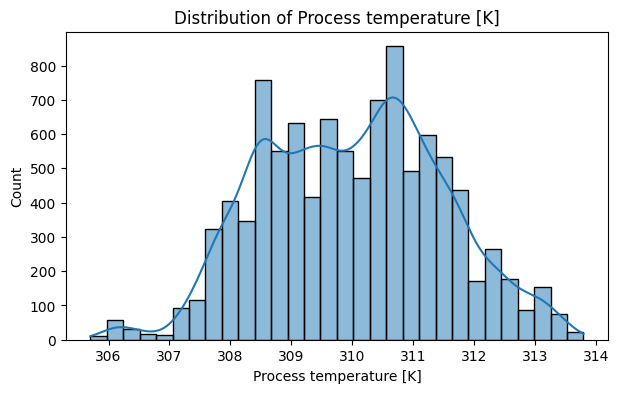

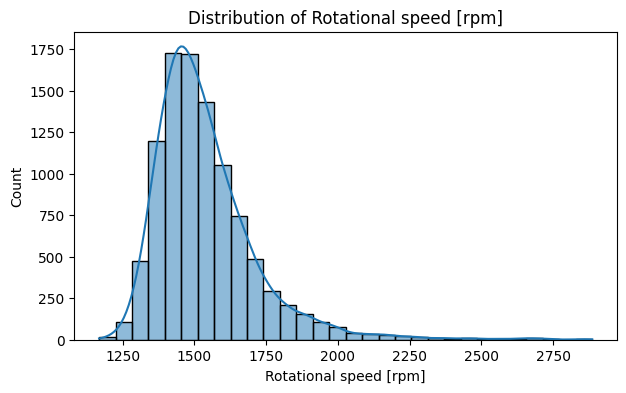

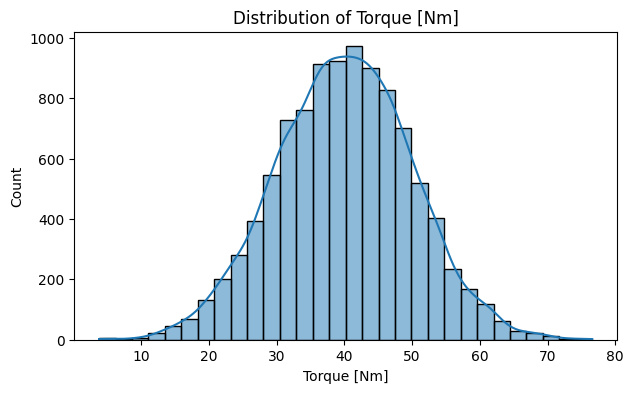

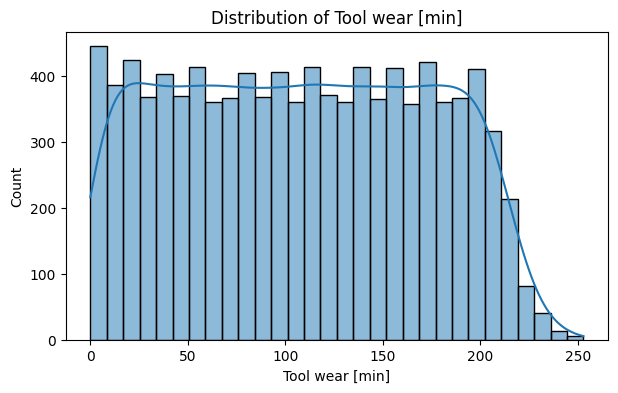

In [22]:
for col in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {col}")

    plt.show()

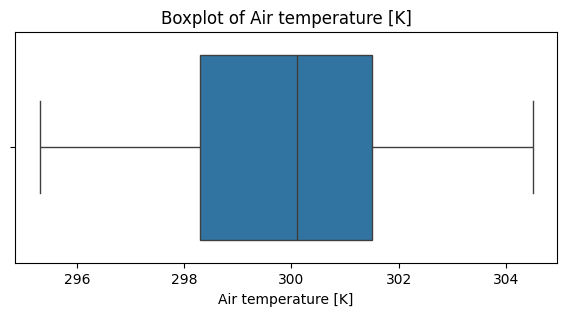

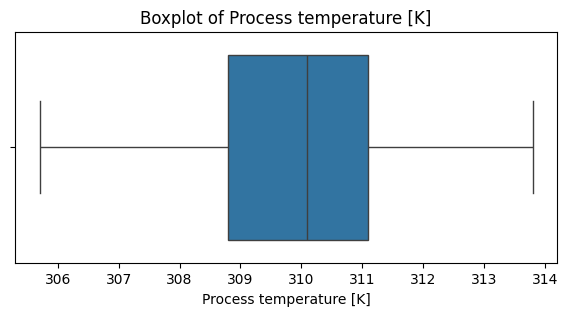

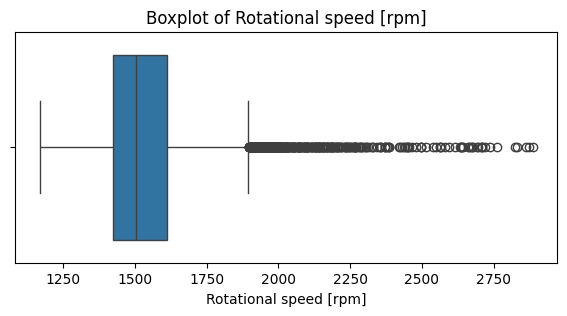

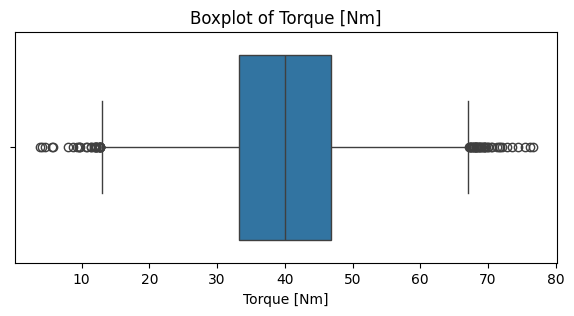

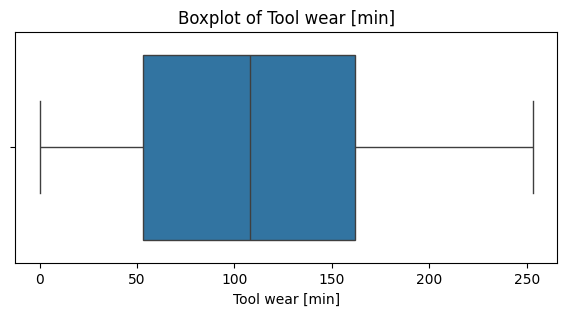

In [23]:
for col in numerical_columns:

    plt.figure(figsize=(7,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

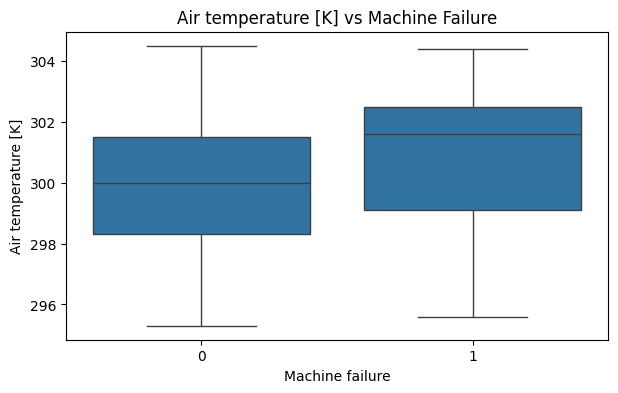

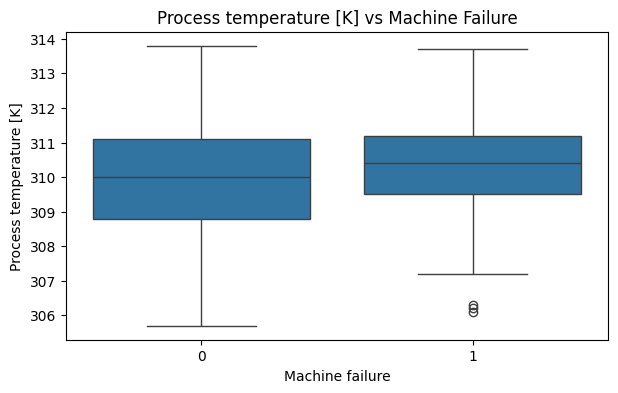

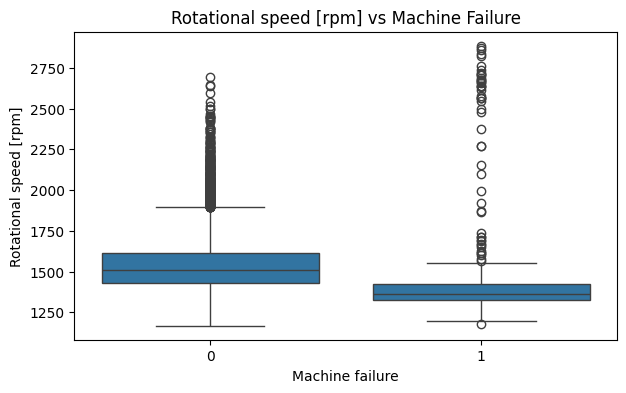

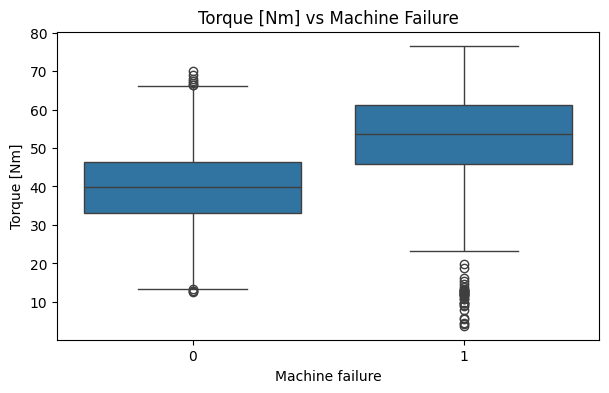

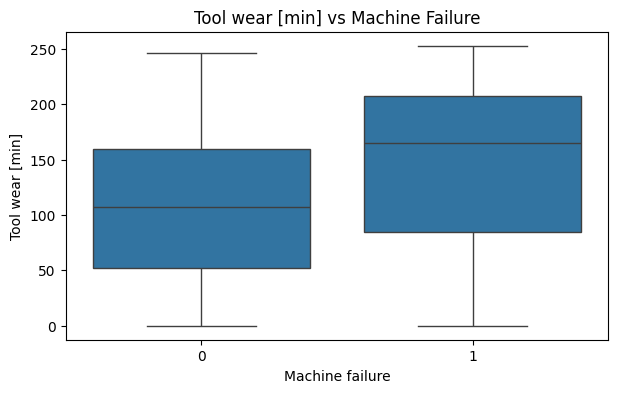

In [24]:
for col in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=df,
        x="Machine failure",
        y=col
    )

    plt.title(f"{col} vs Machine Failure")

    plt.show()

In [25]:
for col in numerical_columns:

    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    outliers=df[(df[col]<lower)|(df[col]>upper)]

    print(f"{col}: {len(outliers)} outliers")

Air temperature [K]: 0 outliers
Process temperature [K]: 0 outliers
Rotational speed [rpm]: 418 outliers
Torque [Nm]: 69 outliers
Tool wear [min]: 0 outliers


In [26]:
failure_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df[failure_columns].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

In [27]:
(df[failure_columns].sum() / len(df) * 100).round(2)

TWF    0.46
HDF    1.15
PWF    0.95
OSF    0.98
RNF    0.19
dtype: float64

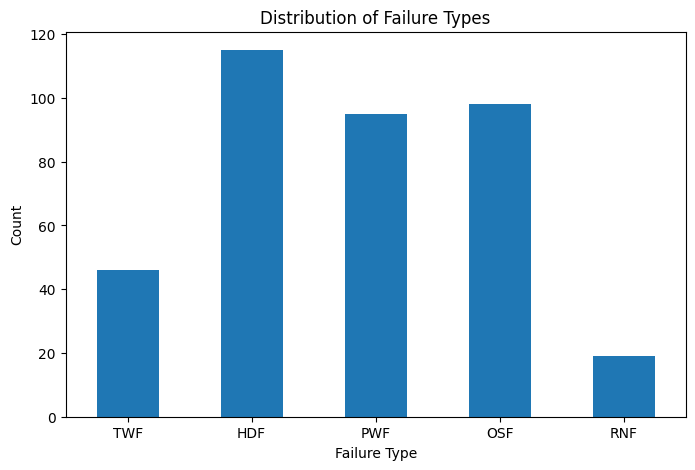

In [28]:
import matplotlib.pyplot as plt

failure_counts = df[failure_columns].sum()

plt.figure(figsize=(8,5))

failure_counts.plot(kind="bar")

plt.title("Distribution of Failure Types")
plt.xlabel("Failure Type")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

In [29]:
df[["Machine failure"] + failure_columns].corr()

,Machine failure,TWF,HDF,PWF,OSF,RNF
Machine failure,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273
OSF,0.531083,0.038243,0.046396,0.115836,1.000000,-0.004341
RNF,0.004516,0.030970,-0.004706,-0.004273,-0.004341,1.000000


In [30]:
corr = df.corr(numeric_only=True)

corr["Machine failure"].sort_values(ascending=False)

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
RNF                        0.004516
UDI                       -0.022892
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64

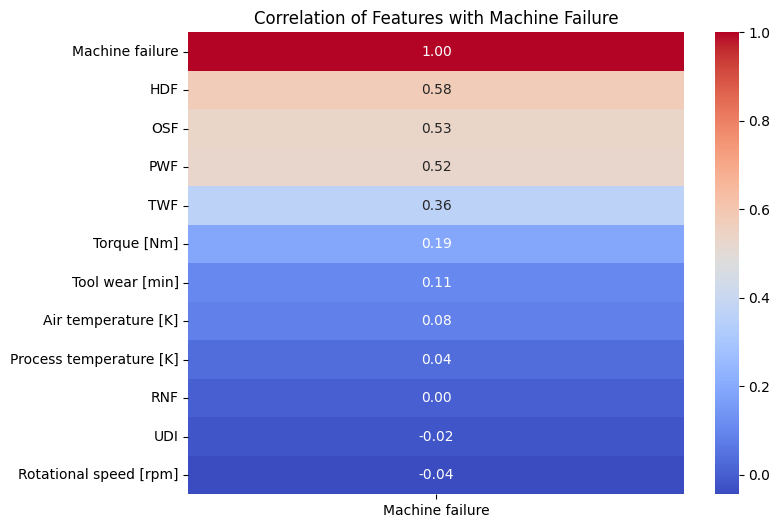

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr[["Machine failure"]].sort_values(by="Machine failure", ascending=False),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Features with Machine Failure")

plt.show()

EDA Summary



The dataset contains 10,000 records and 14 features.
No missing values or duplicate records were found.
The target variable (Machine Failure) is imbalanced, making metrics such as Precision, Recall, and F1-score important during model evaluation.
Product Type L accounts for the majority of production, followed by M and H.
Rotational Speed and Torque contain outliers, which are retained because they likely represent genuine high-stress operating conditions.
Temperature-related features are relatively stable and show no outliers.
The failure indicators (TWF, HDF, PWF, OSF, RNF) provide valuable information about different failure mechanisms and should be analyzed carefully before model development.


## Data Cleaning

In [32]:
df.drop(columns=["UDI"], inplace=True)

In [33]:
df.dtypes

Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [34]:
df_ml = df.copy()

df_ml["Type"] = df_ml["Type"].map({
    "L":0,
    "M":1,
    "H":2
})

In [35]:
df.to_csv("../datasets/clean_ai4i.csv",index=False)

df_ml.to_csv("../datasets/clean_ai4i_ml.csv",index=False)